# Ultimate Data Science Challenge

In [1]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Exploratory Data Analysis

In [2]:
DATA_DIR = Path('/Users/justinku/Documents/GitHub/JustinkSpringboard/Springboard Ultimate Technologies - Take Home Challenge')
logins_df = pd.read_json(DATA_DIR / 'logins.json')
logins_df.head()


,login_time
0,1970-01-01 20:13:18
1,1970-01-01 20:16:10
2,1970-01-01 20:16:37
3,1970-01-01 20:16:36
4,1970-01-01 20:26:21


rows: 93142
exact-timestamp duplicates: 877
parsed timestamps OK: 93142 failed: 0
time span: 1970-01-01 20:00:00 to 1970-04-13 18:45:00
15-min bins: 9788


/var/folders/j4/zp2fvcv16r3_602nppyngwfc0000gn/T/ipykernel_36289/3734553007.py:18: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  counts_15m = logins_df.set_index("login_time").resample("15T")["count"].sum().to_frame()


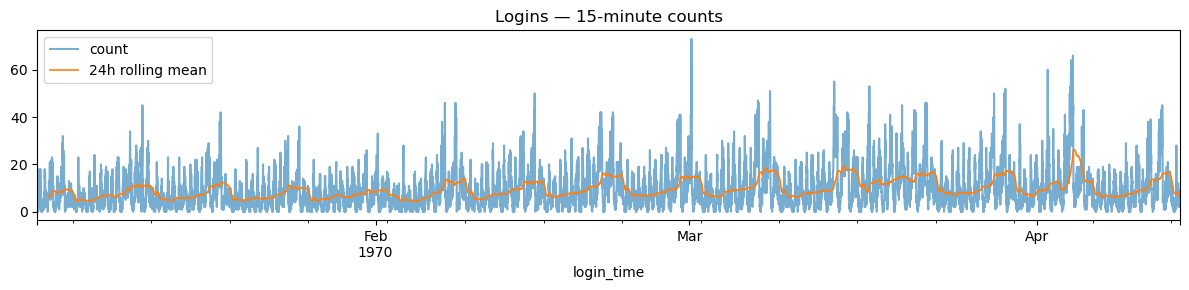

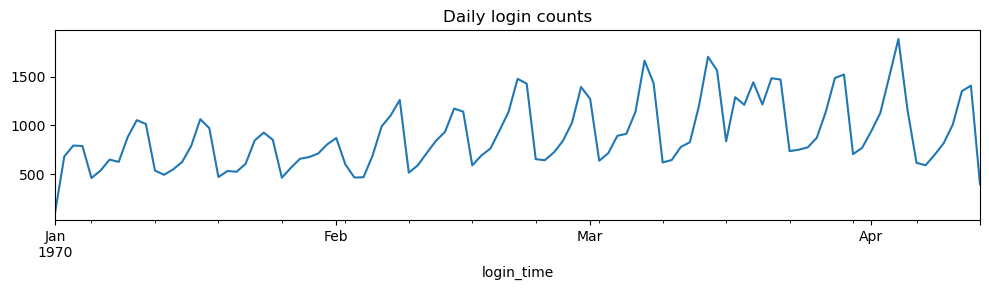

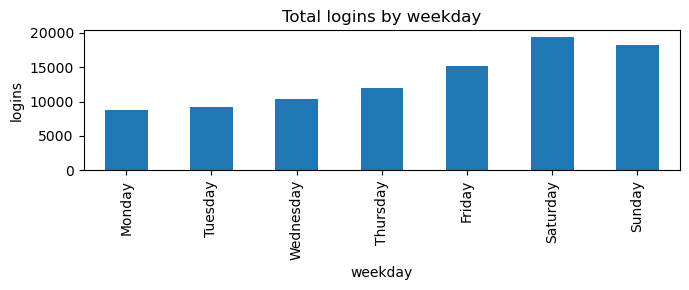

Top 10 busiest 15-min bins:


login_time
1970-03-01 04:30:00    73
1970-04-04 05:30:00    66
1970-04-04 01:30:00    64
1970-04-04 01:15:00    63
1970-04-01 23:30:00    60
1970-04-04 05:00:00    60
1970-04-04 04:45:00    59
1970-04-04 05:15:00    59
1970-04-04 01:45:00    56
1970-03-13 22:15:00    55
Name: count, dtype: int64

In [3]:
cand = [c for c in logins_df.columns if any(k in c.lower() for k in ("time","timestamp","date","login"))]
time_col = cand[0] if cand else logins_df.columns[0]

# parse and sort
logins_df[time_col] = pd.to_datetime(logins_df[time_col], errors="coerce")
print("rows:", len(logins_df))
dups = logins_df.duplicated(subset=[time_col]).sum()
print("exact-timestamp duplicates:", int(dups))
n_valid = logins_df[time_col].notna().sum()
n_bad = len(logins_df) - n_valid
print("parsed timestamps OK:", int(n_valid), "failed:", int(n_bad))

logins_df = logins_df.loc[logins_df[time_col].notna()].sort_values(time_col).reset_index(drop=True)
logins_df = logins_df.rename(columns={time_col: "login_time"})

# add count column and aggregate to 15-min bins
logins_df["count"] = 1
counts_15m = logins_df.set_index("login_time").resample("15T")["count"].sum().to_frame()
counts_15m["count"] = counts_15m["count"].astype(int)
counts_15m.to_csv("logins_15min_counts.csv")

# basic info
start, end = counts_15m.index.min(), counts_15m.index.max()
print("time span:", start, "to", end)
print("15-min bins:", len(counts_15m))

# quick plots
plt.figure(figsize=(12,3))
counts_15m["count"].plot(alpha=0.6)
counts_15m["count"].rolling(96).mean().plot(label="24h rolling mean", linewidth=1.2)
plt.title("Logins — 15-minute counts")
plt.legend(); plt.tight_layout(); plt.show()

# daily totals and weekday summary
daily = counts_15m.resample("D").sum().rename(columns={"count":"daily_count"})
plt.figure(figsize=(10,3))
daily["daily_count"].plot()
plt.title("Daily login counts"); plt.tight_layout(); plt.show()

daily = daily.reset_index()
daily["weekday"] = daily["login_time"].dt.day_name()
by_day = daily.groupby("weekday")["daily_count"].sum().reindex(
    ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
)
plt.figure(figsize=(7,3))
by_day.plot(kind="bar", color="C0")
plt.title("Total logins by weekday"); plt.ylabel("logins"); plt.tight_layout(); plt.show()

# top peaks
print("Top 10 busiest 15-min bins:")
display(counts_15m["count"].nlargest(10))

#### I aggregated the timestamps into 15-minute bins, inspected the daily and weekly patterns, and verfied basic data quality

#### The demand follows a strong daily cycle with weekend peaks and occasional short bursts. Weekends are showing higher demand than the weekdays. 

# Experiment and Metrics Design

### 1) What would you choose as the key measure of success of this experiment in encouraging driver partners to serve both cities, and why would you choose this metric?

#### The primary metric I would use to measure the success of this experiment is the "% of drivers serving both cities in a rolling 7-day window". I would choose this metric as it directly measures the behavior targeted by the Ultimate managers and is easy to explain and convert to a cost/benefit.

### 2) Describe a practical experiment you would design to compare the effectiveness of the proposed change in relation to the key measure of success. Please provide details on:


### a) how you will implement the experiment

#### If possible, data points would be the individual drivers. I would make two groups. One group would fully be reimbursed for the tolls, the other group would not. I randomize example features like 'home city', 'day/night departure', and 'cross-city behavior'. A RF Classifier model would be created with a target label of 'both cities' to say whether a driver will work both cities in a week. Two forests will be created - one using the treatment data and the other using the control data. For each driver, both forest models will be asked the chance that this driver will work both cities. The difference between the two results will be what we are curious about. Those differences will be avereaged to see whre the program works best.

### b) what statistical test(s) you will conduct to verify the significance of the observation

#### I would compare the % of drivers working both cities in Treatment vs Control using a Chi-Square test. I would then report the percentage point difference and a 95% confidence interval.

### c) how you would interpret the results and provide recommendations to the city operations team along with any caveats

#### If the result from the Chi-Square test is clearly positive, you can interpret that as "reimbursing tolls causes more drivers to work both cities". If that is the case, I would recommend that this reimbursement policy be rolled out.

# Predictive Modeling

In [1]:
import pandas as pd, numpy as np
from pathlib import Path
from datetime import timedelta

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report

In [2]:
DATA_DIR = Path('/Users/justinku/Documents/GitHub/JustinkSpringboard/Springboard Ultimate Technologies - Take Home Challenge')  # note the "-" not "–"
fp = DATA_DIR / 'ultimate_data_challenge.json'
print("Exists?", fp.exists(), "\nPath:", fp)

df = pd.read_json(fp)  # if this errors, continue to step 2
df.head()

Exists? True 
Path: /Users/justinku/Documents/GitHub/JustinkSpringboard/Springboard Ultimate Technologies - Take Home Challenge/ultimate_data_challenge.json


,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
0,King's Landing,4,2014-01-25,4.7,1.10,2014-06-17,iPhone,15.4,True,46.2,3.67,5.0
1,Astapor,0,2014-01-29,5.0,1.00,2014-05-05,Android,0.0,False,50.0,8.26,5.0
2,Astapor,3,2014-01-06,4.3,1.00,2014-01-07,iPhone,0.0,False,100.0,0.77,5.0
3,King's Landing,9,2014-01-10,4.6,1.14,2014-06-29,iPhone,20.0,True,80.0,2.36,4.9
4,Winterfell,14,2014-01-27,4.4,1.19,2014-03-15,Android,11.8,False,82.4,3.13,4.9


In [3]:
# parsing dates

for c in ["signup_date","last_trip_date"]:
    df[c] = pd.to_datetime(df[c], errors="coerce") 

In [ ]:
# cutoff: “active in last 30 days” from the latest observed date

cutoff = df["last_trip_date"].max()
df["retained"] = (df["last_trip_date"] >= (cutoff - pd.Timedelta(days=30))).astype(int)




print("cutoff:", cutoff.date())
print(df["retained"].value_counts(normalize=True).rename("share"))

cutoff: 2014-07-01
retained
0    0.62392
1    0.37608
Name: share, dtype: float64


In [5]:
target = "retained"
y = df[target]


In [6]:
num_cols = [
    "avg_dist",
    "avg_rating_by_driver",
    "avg_rating_of_driver",
    "surge_pct",
    "avg_surge",
    "trips_in_first_30_days",
    "weekday_pct",
]
cat_cols = ["city","phone","ultimate_black_user"]  # treat boolean as categorical for simplicity

X = df[num_cols + cat_cols].copy()

In [7]:
num_pipe = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
])

cat_pipe = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

pre = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ]
)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [9]:
logit = Pipeline(steps=[
    ("pre", pre),
    ("clf", LogisticRegression(max_iter=1000, n_jobs=None))
])
logit.fit(X_train, y_train)

p_logit = logit.predict_proba(X_test)[:,1]
auc_logit = roc_auc_score(y_test, p_logit)
print(f"[LogReg] ROC-AUC: {auc_logit:.3f}")

[LogReg] ROC-AUC: 0.755


In [10]:
rf = Pipeline(steps=[
    ("pre", pre),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ))
])
rf.fit(X_train, y_train)

p_rf = rf.predict_proba(X_test)[:,1]
auc_rf = roc_auc_score(y_test, p_rf)
print(f"[RandomForest] ROC-AUC: {auc_rf:.3f}")

[RandomForest] ROC-AUC: 0.849


In [11]:
yhat_rf = (p_rf >= 0.5).astype(int)
print("\n[RandomForest] Test set classification report @0.5:")
print(classification_report(y_test, yhat_rf, digits=3))


[RandomForest] Test set classification report @0.5:
              precision    recall  f1-score   support

           0      0.804     0.859     0.831      7799
           1      0.737     0.653     0.693      4701

    accuracy                          0.782     12500
   macro avg      0.771     0.756     0.762     12500
weighted avg      0.779     0.782     0.779     12500



In [12]:
ohe = rf.named_steps["pre"].named_transformers_["cat"].named_steps["onehot"]
cat_names = list(ohe.get_feature_names_out(cat_cols))
feature_names = num_cols + cat_names

importances = rf.named_steps["clf"].feature_importances_
imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10)
print("\nTop 10 features (Random Forest):")
print(imp)


Top 10 features (Random Forest):
avg_dist                  0.172606
avg_rating_by_driver      0.142458
weekday_pct               0.131981
surge_pct                 0.100019
trips_in_first_30_days    0.079845
avg_surge                 0.078051
city_King's Landing       0.076799
avg_rating_of_driver      0.064590
phone_Android             0.030931
phone_iPhone              0.029276
dtype: float64


In [14]:
retained_rate = float(df["retained"].mean())


In [16]:
print(f"Retained fraction: {retained_rate:.1%}")
print(f"ROC-AUC (LogReg): {auc_logit:.3f}  |  ROC-AUC (RF): {auc_rf:.3f}")
print("Top signals (RF):")
for k,v in imp.items():
    print(f"  - {k} (importance={v:.3f})")

Retained fraction: 37.6%
ROC-AUC (LogReg): 0.755  |  ROC-AUC (RF): 0.849
Top signals (RF):
  - avg_dist (importance=0.173)
  - avg_rating_by_driver (importance=0.142)
  - weekday_pct (importance=0.132)
  - surge_pct (importance=0.100)
  - trips_in_first_30_days (importance=0.080)
  - avg_surge (importance=0.078)
  - city_King's Landing (importance=0.077)
  - avg_rating_of_driver (importance=0.065)
  - phone_Android (importance=0.031)
  - phone_iPhone (importance=0.029)


### What fraction of the observed users were retained?
##### Of the observed users, 37.6% were retained.


### How valid is your model?
##### I trained a logistic regression baseline and a RF. For a first pass, my model has good AUC and no visible leakage.


### How might Ultimate leverage the insights gained?
##### Ultimate could give small rewards for the first month. The features point to "early usage drives retention". Another thing Ultimate could do is reach out via email or messages to people around the 20-25 day mark as if the individual looks at-risk.